# LendingClub Credit Risk — Macro Data vs. Early-Warning Signals for Cutoff Strategy

The walk-forward backtest in `scorecard.ipynb` (Section 12) found that cutoffs
chosen from historical data kept losing money in 2016–2018: the scorecard still
*ranked* borrowers well, but the overall level of defaults rose and a
backward-looking cutoff could not see it coming. The README concluded that
production use needs **leading indicators**.

This notebook tests two candidate leading indicators:

1. **Macroeconomic and sentiment data** (FRED): state unemployment, University of
   Michigan consumer sentiment, the St. Louis Fed financial stress index, and the
   US consumer-loan delinquency rate — the kind of forward-looking information
   IFRS 9 expects in provisioning.
2. **The lender's own early-warning signal**: the share of recently issued loans
   that stopped paying within their first few payments — observable 3–6 months
   after issue, long before 12-month outcomes are known.

Each is judged on the same three questions: does it improve borrower ranking,
does it fix the drift in the predicted default *level*, and does a cutoff that
adjusts with it produce a better approved book?

Everything uses only information available at the time of each decision:
macro series are lagged by their publication delay, and early-warning reads by
the time it takes for them to become observable (3–6 months).

In [1]:
import glob
import urllib.request
from pathlib import Path

import kagglehub
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")

## 1. Load all loans — not only resolved ones

Same features and FICO-percentile construction as `scorecard.ipynb`, but keeping
every loan (current, late, paid, charged off), plus `addr_state` and
`last_pymnt_d` for the steps below.

In [2]:
usecols = [
    "loan_amnt", "funded_amnt", "total_pymnt", "term", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "application_type", "acc_open_past_24mths", "bc_open_to_buy",
    "mths_since_recent_bc", "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl", "num_actv_rev_tl", "num_rev_tl_bal_gt_0",
    "num_tl_op_past_12m", "tot_hi_cred_lim", "total_bc_limit",
    "percent_bc_gt_75", "grade", "sub_grade", "int_rate",
    "addr_state", "last_pymnt_d",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 41)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

df = df[df["application_type"] == "Individual"].copy()

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

## 2. A default measure that is comparable across years

The earlier notebooks use **resolved loans only** (fully paid or charged off).
That is fine for ranking, but it distorts the default *level* for recent
vintages: the data ends in 2018Q4, so most 2016–2018 loans were still running,
and loans that default resolve sooner than loans that are repaid. Recent
vintages therefore look worse than they are.

A consistent alternative is a fixed horizon: **default within 12 months of
issue** (`bad12`). This counts a loan as bad if it charged off or is 31+ days
late and its last payment came within 7 months of issue (a missed payment by
month 8, charge-off typically following around 4–5 months later). It uses
every loan, and it is fully observed for everything issued up to December 2017.

In [5]:
status = df["loan_status"].str.replace("Does not meet the credit policy. Status:", "", regex=False)
df["last_pymnt_d"] = pd.to_datetime(df["last_pymnt_d"], format="%b-%Y")
months_paid = ((df["last_pymnt_d"].dt.year - df["issue_d"].dt.year) * 12
               + (df["last_pymnt_d"].dt.month - df["issue_d"].dt.month))
stopped_paying = status.isin(["Charged Off", "Default", "Late (31-120 days)"])
df["bad12"] = (stopped_paying & (months_paid.isna() | (months_paid <= 7))).astype(int)

# early-warning events (any delinquency status counts): stopped paying within the first ~4 payments,
# and the faster first-payment-default read
delinquent_any = status.isin(["Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)", "In Grace Period"])
df["early_bad"] = (delinquent_any & (months_paid.isna() | (months_paid <= 3))).astype(int)
df["fpd"] = (delinquent_any & (months_paid.isna() | (months_paid <= 1))).astype(int)  # first-payment default

resolved_mask = status.isin(["Charged Off", "Default", "Fully Paid"])
by_year = df.groupby(df["issue_d"].dt.year).agg(loans=("bad12", "size"), default_12m=("bad12", "mean"),
                                                 early_default=("early_bad", "mean"))
by_year["share_resolved"] = resolved_mask.groupby(df["issue_d"].dt.year).mean()
by_year["resolved_only_default"] = status[resolved_mask].isin(["Charged Off", "Default"]).groupby(
    df.loc[resolved_mask, "issue_d"].dt.year).mean()
by_year.loc[2009:2017].round(4)

,loans,default_12m,early_default,share_resolved,resolved_only_default
issue_d,,,,,
2009,5281,0.0365,0.0142,1.0000,0.1369
2010,12537,0.0254,0.0089,1.0000,0.1401
2011,21721,0.0267,0.0090,1.0000,0.1518
2012,53367,0.0263,0.0082,1.0000,0.1620
2013,134814,0.0217,0.0066,0.9999,0.1560
2014,235629,0.0235,0.0064,0.9468,0.1845
2015,420584,0.0275,0.0075,0.8920,0.2018
2016,425618,0.0330,0.0094,0.6762,0.2326
2017,401154,0.0316,0.0101,0.3896,0.2279


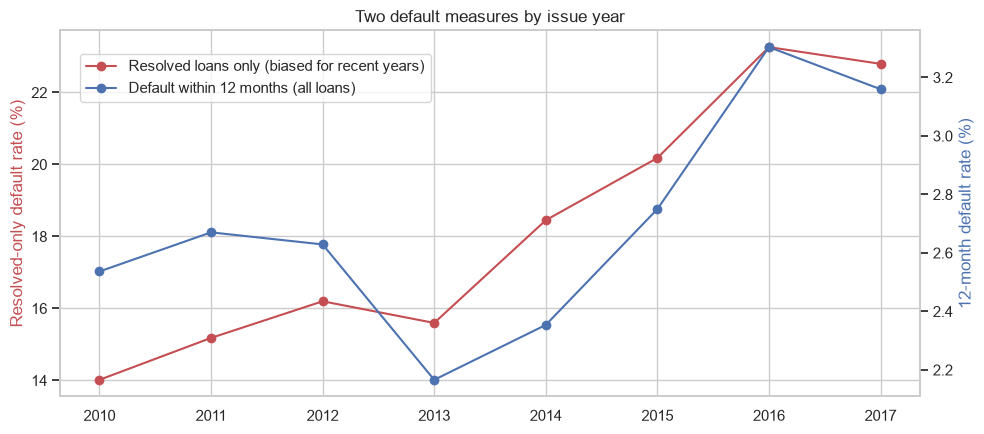

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
yrs = by_year.loc[2010:2017]
ax.plot(yrs.index, yrs["resolved_only_default"] * 100, marker="o", color="#C44E52", label="Resolved loans only (biased for recent years)")
ax2 = ax.twinx()
ax2.plot(yrs.index, yrs["default_12m"] * 100, marker="o", color="#4C72B0", label="Default within 12 months (all loans)")
ax.set_ylabel("Resolved-only default rate (%)", color="#C44E52")
ax2.set_ylabel("12-month default rate (%)", color="#4C72B0")
ax2.grid(False)
ax.set_title("Two default measures by issue year")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.show()

## 3. Macro and sentiment data (FRED)

Downloaded from FRED and cached in `data/macro/`. Each series is aligned to the
information a lender would actually have had in the application month:

| Series | FRED id | Lag applied |
|---|---|---|
| State unemployment rate (matched on `addr_state`) | `{ST}UR` | 2 months, plus its 12-month change |
| University of Michigan consumer sentiment | `UMCSENT` | 1 month |
| St. Louis Fed financial stress index (weekly, monthly mean) | `STLFSI4` | 1 month |
| Delinquency rate on consumer loans, all commercial banks (quarterly) | `DRCLACBS` | quarter end + 2 months |

Caveat: FRED serves today's revised figures, not the originally published
ones; state unemployment in particular is revised annually. A production
backtest would use ALFRED real-time vintages.

In [7]:
MACRO_DIR = Path("../data/macro")
MACRO_DIR.mkdir(parents=True, exist_ok=True)
STATES = sorted(df["addr_state"].dropna().unique())


def fred(series_id):
    f = MACRO_DIR / f"{series_id}.csv"
    if not f.exists():
        urllib.request.urlretrieve(f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}", f)
    s = pd.read_csv(f, parse_dates=["observation_date"]).set_index("observation_date")[series_id]
    return pd.to_numeric(s, errors="coerce")


national = pd.DataFrame({
    "sentiment": fred("UMCSENT").resample("MS").mean().shift(1),
    "fin_stress": fred("STLFSI4").resample("MS").mean().shift(1),
})
delinq = fred("DRCLACBS")
delinq.index = delinq.index + pd.DateOffset(months=5)  # quarter start -> quarter end (+3) -> published (+2)
national["cons_delinq"] = delinq.resample("MS").ffill()
national = national.ffill()

state_unemp = pd.DataFrame({st: fred(f"{st}UR") for st in STATES})
state_level = state_unemp.shift(2).stack().rename("state_unemp")
state_change = (state_unemp.shift(2) - state_unemp.shift(14)).stack().rename("state_unemp_chg12")

df = df.join(national, on="issue_d")
key = pd.MultiIndex.from_arrays([df["issue_d"], df["addr_state"]])
df["state_unemp"] = state_level.reindex(key).values
df["state_unemp_chg12"] = state_change.reindex(key).values

df = df[(df["issue_d"] >= "2009-01-01") & (df["issue_d"] <= "2017-12-01")].copy()
MACRO = ["state_unemp", "state_unemp_chg12", "sentiment", "fin_stress", "cons_delinq"]
print(f"{len(df):,} loans issued 2009-2017; missing macro values: {df[MACRO].isna().mean().max():.2%}")

1,710,705 loans issued 2009-2017; missing macro values: 0.00%


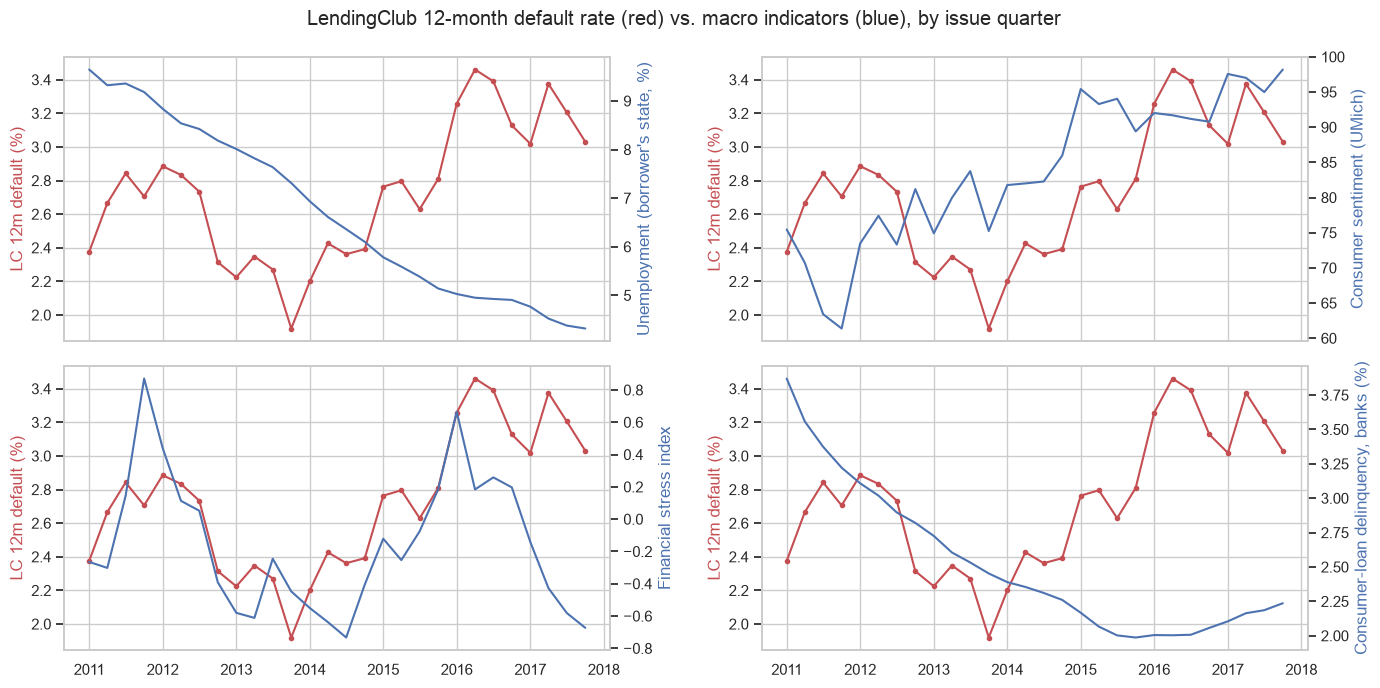

Correlation of quarterly 12m default rate with each indicator (2011-2017):


state_unemp   -0.55
sentiment      0.49
fin_stress     0.47
cons_delinq   -0.35
Name: default_12m, dtype: float64

In [8]:
quarterly = df.groupby(df["issue_d"].dt.to_period("Q")).agg(
    default_12m=("bad12", "mean"), state_unemp=("state_unemp", "mean"), sentiment=("sentiment", "mean"),
    fin_stress=("fin_stress", "mean"), cons_delinq=("cons_delinq", "mean"))
q = quarterly.loc["2011Q1":]
x = q.index.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, col, label in zip(axes.flat, ["state_unemp", "sentiment", "fin_stress", "cons_delinq"],
                          ["Unemployment (borrower's state, %)", "Consumer sentiment (UMich)",
                           "Financial stress index", "Consumer-loan delinquency, banks (%)"]):
    ax.plot(x, q["default_12m"] * 100, color="#C44E52", marker="o", markersize=3)
    ax.set_ylabel("LC 12m default (%)", color="#C44E52")
    ax2 = ax.twinx()
    ax2.plot(x, q[col], color="#4C72B0")
    ax2.set_ylabel(label, color="#4C72B0")
    ax2.grid(False)
plt.suptitle("LendingClub 12-month default rate (red) vs. macro indicators (blue), by issue quarter")
plt.tight_layout()
plt.show()

print("Correlation of quarterly 12m default rate with each indicator (2011-2017):")
q.corr()["default_12m"].drop("default_12m").round(2)

## 4. Does macro data improve the default model?

Monotonic LightGBM predicting `bad12` from the same 22 application features,
trained on loans issued 2009–2014 (early-stopped on 2014) and tested blind on
2015, 2016 and 2017 — with and without the macro features. Macro features are
monotonically constrained in the economically expected direction (higher
unemployment, stress and delinquency raise risk; higher sentiment lowers it).

In [9]:
BASE = [
    "loan_to_income", "fico_percentile", "acc_open_past_24mths", "dti", "num_tl_op_past_12m",
    "bc_open_to_buy", "mo_sin_rcnt_tl", "total_bc_limit", "tot_hi_cred_lim", "mths_since_recent_inq",
    "loan_amnt", "mo_sin_rcnt_rev_tl_op", "percent_bc_gt_75", "num_actv_rev_tl", "num_rev_tl_bal_gt_0",
    "annual_inc", "mths_since_recent_bc", "mort_acc", "revol_util", "term_months",
    "verification_status", "home_ownership",
]
INCREASES_RISK = {
    "loan_to_income", "acc_open_past_24mths", "dti", "num_tl_op_past_12m", "loan_amnt", "percent_bc_gt_75",
    "num_actv_rev_tl", "num_rev_tl_bal_gt_0", "revol_util", "term_months",
    "state_unemp", "state_unemp_chg12", "fin_stress", "cons_delinq",
}
DECREASES_RISK = {
    "fico_percentile", "bc_open_to_buy", "mo_sin_rcnt_tl", "total_bc_limit", "tot_hi_cred_lim",
    "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op", "annual_inc", "mths_since_recent_bc", "mort_acc",
    "sentiment",
}
for col in ["verification_status", "home_ownership"]:
    df[col] = df[col].astype("category")

FEATURE_SETS = {
    "Application data only": BASE,
    "+ state unemployment": BASE + ["state_unemp", "state_unemp_chg12"],
    "+ all macro & sentiment": BASE + MACRO,
}
PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31, min_child_samples=1000,
              feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=10.0,
              verbose=-1, seed=0, num_threads=8, monotone_constraints_method="advanced")

train = df[df["issue_d"] < "2015-01-01"]
test = df[df["issue_d"] >= "2015-01-01"].copy()
fit_part, stop_part = train[train["issue_d"] < "2014-01-01"], train[train["issue_d"] >= "2014-01-01"]

models, rows = {}, []
for name, feats in FEATURE_SETS.items():
    params = dict(PARAMS, monotone_constraints=[1 if f in INCREASES_RISK else -1 if f in DECREASES_RISK else 0 for f in feats])
    probe = lgb.train(params, lgb.Dataset(fit_part[feats], fit_part["bad12"]), 2000,
                      valid_sets=[lgb.Dataset(stop_part[feats], stop_part["bad12"])],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
    model = lgb.train(params, lgb.Dataset(train[feats], train["bad12"]), probe.best_iteration)
    models[name] = (model, feats)
    test[f"pd::{name}"] = model.predict(test[feats])
    for year in [2015, 2016, 2017]:
        yr = test[test["issue_d"].dt.year == year]
        rows.append({"model": name, "year": year,
                     "gini": 2 * roc_auc_score(yr["bad12"], yr[f"pd::{name}"]) - 1,
                     "predicted_default": yr[f"pd::{name}"].mean(), "actual_default": yr["bad12"].mean()})

macro_test = pd.DataFrame(rows)
macro_test["actual / predicted"] = macro_test["actual_default"] / macro_test["predicted_default"]
macro_test.pivot(index="model", columns="year", values=["gini", "actual / predicted"]).round(3)

gini               actual / predicted              
year                      2015   2016   2017               2015   2016   2017
model                                                                        
+ all macro & sentiment  0.365  0.351  0.349              1.152  1.460  1.541
+ state unemployment     0.368  0.352  0.350              1.156  1.477  1.560
Application data only    0.367  0.352  0.350              1.120  1.427  1.497

## 5. The early-warning signal

For each issue month, the observed early-default rate is compared with what the
model expected for that month's mix of borrowers:

`ratio(v) = early-default rate of vintage v / mean model PD of vintage v`

Two reads, differing in speed:

| Read | Event | Known after |
|---|---|---|
| **Fast** | first-payment default: stopped paying by the 1st–2nd payment | ~3 months |
| **Slow** | early default: stopped paying within the first ~4 payments | ~6 months |

For an application in month *m*, the signal averages the three most recent
vintages that are already readable (issued 3–5 months earlier for the fast read,
6–8 for the slow one) and expresses the result relative to 2013–2014:

`k(m) = mean ratio over the latest readable vintages  ÷  mean ratio over 2013–2014`

`k > 1` means recent loans are going bad faster than the model expects for their
risk mix. The **recalibrated PD** is `model PD × k(m)`: ranking is unchanged,
only the level moves.

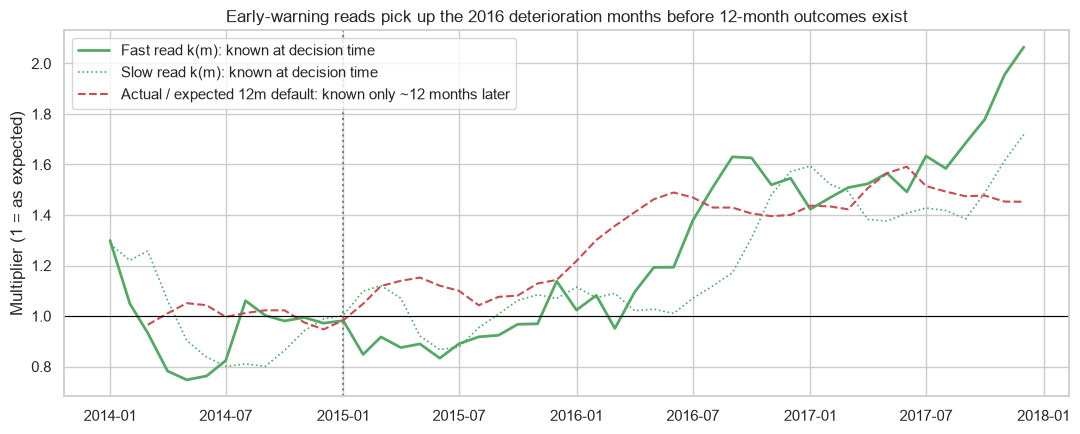

issue_d,2015-01-01,2015-04-01,2015-07-01,2015-10-01,2016-01-01,2016-04-01,2016-07-01,2016-10-01,2017-01-01,2017-04-01,2017-07-01,2017-10-01
k_fast,0.92,0.87,0.91,1.02,1.02,1.16,1.51,1.56,1.47,1.53,1.63,1.93
k_slow,1.07,0.95,0.95,1.07,1.09,1.02,1.12,1.45,1.54,1.39,1.41,1.61


In [10]:
base_model, base_feats = models["Application data only"]
df["pd_base"] = base_model.predict(df[base_feats])  # in-sample before 2015, out-of-sample from 2015

READS = {"fast": ("fpd", 3), "slow": ("early_bad", 6)}  # (event column, months until readable)
vintage = df.groupby("issue_d").agg(loans=("bad12", "size"), model_pd=("pd_base", "mean"),
                                    default_12m=("bad12", "mean"), fpd=("fpd", "mean"), early_bad=("early_bad", "mean"))
for read, (event, lag) in READS.items():
    ratio = vintage[event] / vintage["model_pd"]
    reference = ratio.loc["2013-01-01":"2014-12-01"].mean()
    vintage[f"k_{read}"] = ratio.rolling(3).mean().shift(lag) / reference  # only vintages readable at month m
    test = test.join(vintage[f"k_{read}"], on="issue_d")
    test[f"pd_recal_{read}"] = test["pd::Application data only"] * test[f"k_{read}"]

v = vintage.loc["2014-01-01":]
train_level = (vintage.loc["2013-01-01":"2014-12-01", "default_12m"].sum()
               / vintage.loc["2013-01-01":"2014-12-01", "model_pd"].sum())
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(v.index, v["k_fast"], color="#55A868", linewidth=2, label="Fast read k(m): known at decision time")
ax.plot(v.index, v["k_slow"], color="#55A868", linewidth=1.2, linestyle=":", label="Slow read k(m): known at decision time")
ax.plot(v.index, (v["default_12m"] / v["model_pd"] / train_level).rolling(3).mean(), color="#C44E52",
        linestyle="--", label="Actual / expected 12m default: known only ~12 months later")
ax.axhline(1, color="black", linewidth=0.8)
ax.axvline(pd.Timestamp("2015-01-01"), color="grey", linestyle=":")
ax.set_ylabel("Multiplier (1 = as expected)")
ax.set_title("Early-warning reads pick up the 2016 deterioration months before 12-month outcomes exist")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

vintage.loc["2015-01-01":"2017-12-01", ["k_fast", "k_slow"]].resample("QS").mean().round(2).T

In [11]:
candidates = {
    "Application data only": "pd::Application data only",
    "+ all macro & sentiment": "pd::+ all macro & sentiment",
    "Early-warning recalibrated (fast read)": "pd_recal_fast",
    "Early-warning recalibrated (slow read)": "pd_recal_slow",
}
calib_rows = []
for year in [2015, 2016, 2017]:
    yr = test[test["issue_d"].dt.year == year]
    for label, col in candidates.items():
        calib_rows.append({"year": year, "approach": label, "calibration_error": yr[col].mean() / yr["bad12"].mean() - 1})
calibration = pd.DataFrame(calib_rows).pivot(index="approach", columns="year", values="calibration_error")
print("Predicted vs actual 12-month default rate (negative = under-predicting risk):")
calibration.loc[list(candidates)].round(3)

Predicted vs actual 12-month default rate (negative = under-predicting risk):


year,2015,2016,2017
approach,,,
Application data only,-0.107,-0.299,-0.332
+ all macro & sentiment,-0.132,-0.315,-0.351
Early-warning recalibrated (fast read),-0.162,-0.103,0.099
Early-warning recalibrated (slow read),-0.099,-0.185,-0.009


## 6. Cutoff strategy

Four approve/decline policies are applied month by month to 2015–2017 applicants:

- **Static:** approve if PD is at or below the cutoff that gave a 70% approval
  rate in training. This is what a lender would have run.
- **Macro-aware:** the same approach using the model with macro and sentiment
  features.
- **Early-warning (tighten-only):** approve if `PD × max(k_fast, 1)` is at or
  below the static cutoff. The cutoff tightens when recent vintages go bad faster
  than expected, and never loosens below the static policy — how a credit
  committee would actually use such a trigger.
- **Hindsight benchmark:** a static cutoff chosen *after the fact* to give the
  same overall approval rate as the early-warning policy. Not available in real
  time; it separates *how much* to tighten from *when*.

In [12]:
train_pd_base = base_model.predict(train[base_feats])
cut_base = np.quantile(train_pd_base, 0.70)
macro_model, macro_feats = models["+ all macro & sentiment"]
cut_macro = np.quantile(macro_model.predict(train[macro_feats]), 0.70)

pd_base_test = test["pd::Application data only"]
test["approve::Static"] = pd_base_test <= cut_base
test["approve::Macro-aware"] = test["pd::+ all macro & sentiment"] <= cut_macro
test["approve::Early-warning"] = pd_base_test * test["k_fast"].clip(lower=1) <= cut_base
hindsight_cut = np.quantile(pd_base_test, test["approve::Early-warning"].mean())
test["approve::Hindsight benchmark"] = pd_base_test <= hindsight_cut
POLICIES = ["Static", "Macro-aware", "Early-warning", "Hindsight benchmark"]

summary_rows = []
for policy in POLICIES:
    approve = test[f"approve::{policy}"]
    row = {"policy": policy, "approval_rate": approve.mean(),
           "approved_12m_default": test.loc[approve, "bad12"].mean(),
           "defaults_approved": int(test.loc[approve, "bad12"].sum())}
    for year in [2015, 2016, 2017]:
        in_year = test["issue_d"].dt.year == year
        row[f"default_{year}"] = test.loc[approve & in_year, "bad12"].mean()
    summary_rows.append(row)
policy_summary = pd.DataFrame(summary_rows).set_index("policy")
policy_summary.round(4)

,approval_rate,approved_12m_default,defaults_approved,default_2015,default_2016,default_2017
policy,,,,,,
Static,0.7175,0.0208,18631,0.0172,0.0223,0.0227
Macro-aware,0.7325,0.0213,19455,0.0177,0.0227,0.0232
Early-warning,0.5604,0.0174,12180,0.0170,0.0191,0.0158
Hindsight benchmark,0.5604,0.0172,12056,0.0140,0.0185,0.0189


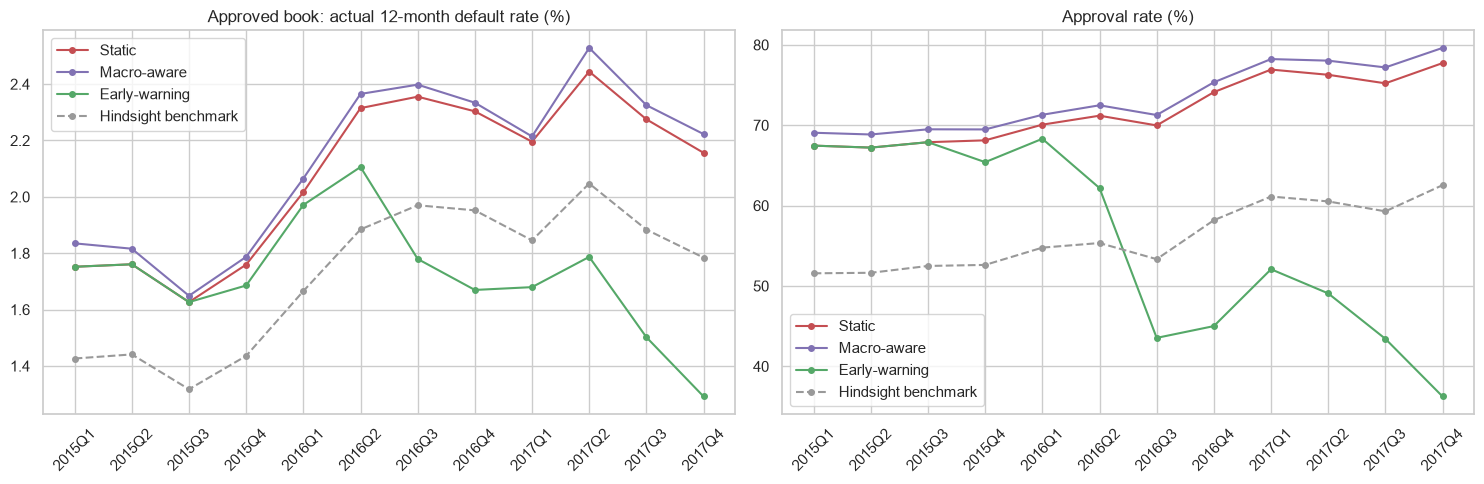

In [13]:
quarter = test["issue_d"].dt.to_period("Q")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"Static": "#C44E52", "Macro-aware": "#8172B3", "Early-warning": "#55A868", "Hindsight benchmark": "#999999"}
for policy in POLICIES:
    approve = test[f"approve::{policy}"]
    bad_q = test.loc[approve, "bad12"].groupby(quarter[approve]).mean()
    appr_q = approve.groupby(quarter).mean()
    style = dict(color=colors[policy], marker="o", markersize=4, label=policy,
                 linestyle="--" if policy == "Hindsight benchmark" else "-")
    axes[0].plot(bad_q.index.astype(str), bad_q * 100, **style)
    axes[1].plot(appr_q.index.astype(str), appr_q * 100, **style)
axes[0].set_title("Approved book: actual 12-month default rate (%)")
axes[1].set_title("Approval rate (%)")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

**Macro and sentiment data would not have helped with LendingClub's 2016–2017
deterioration. The lender's own early-warning signal would have.**

**1. The deterioration was real, but it was not macro-driven.** On a consistent
12-month measure, defaults rose from 2.2% (2013 loans) to 3.3% (2016 loans),
while the economy improved: unemployment fell and consumer sentiment rose.
Over 2011–2017 the quarterly default rate correlates *negatively* with
state unemployment (−0.55) and *positively* with sentiment (+0.49), the
opposite of what macro-based forecasting assumes. Only the financial stress
index moved with it (+0.47), peaking in early 2016. (The resolved-loans-only
rate used in earlier notebooks overstates this, at 23% for 2016, because only
68% of 2016 loans had finished by the end of the data.)

**2. Macro features don't improve the model.** Adding state unemployment,
sentiment, financial stress and industry delinquency changes out-of-time Gini
by less than ±0.003 in every year, and makes the level drift slightly *worse*:
the model under-predicts 2017 defaults by 35% instead of 33%, because the
macro inputs said conditions were improving.

**3. Early-warning recalibration fixes the level.** Scaling PDs by how fast
recent vintages were going bad (relative to their risk mix) cut the 2017
calibration error from −33% to −1% with the slow read, and the 2016 error
from −30% to −10% with the fast read. The fast read (first-payment defaults,
readable after about 3 months) passed 1.15 by mid-2016 and 1.5 by 2016Q3. At
that point the 12-month outcome of loans issued in early 2016 was still six
months away.

**4. A tighten-only early-warning cutoff produces a better book, but by
tightening, not by clever timing.**

| Policy (2015–2017) | Approval | Approved 12m default | Defaults approved |
|---|---|---|---|
| Static (70% in training) | 71.7% | 2.08% | 18,631 |
| Macro-aware | 73.3% | 2.13% | 19,455 |
| **Early-warning, tighten-only** | 56.0% | **1.74%** | **12,180** |
| Hindsight static at the same approval | 56.0% | 1.72% | 12,056 |

Compared with the policy a lender would have run, the early-warning trigger
cuts approved-book defaults by 35%. In 2017 its approved book defaulted at
1.58%, against 2.27% for the static cutoff. The macro-aware policy moved the
wrong way, approving *more*. The hindsight benchmark matches the
early-warning result overall. Its value is therefore that it tells you
**how much to tighten, and when, without hindsight**. Because the ranking
model is the same, it doesn't find better borrowers.

**Implications for practice**
- For IFRS 9 and PD calibration, macro overlays capture the economic cycle but
  miss lender-specific and segment-specific shifts: underwriting drift, funding
  shocks (LendingClub's 2016 crisis), competitor behaviour. Early-vintage
  performance monitoring should sit alongside the macro scenarios, as an
  additional overlay or a trigger for recalibration.
- For cutoff strategy, a tighten-only trigger on early-vintage performance is
  simple to govern and would have limited the damage. Loosening should stay a
  deliberate credit-committee decision.

**Caveats**
- `bad12` is reconstructed from a single end-of-data snapshot (status and
  last-payment date), not monthly delinquency history.
- Tighter approval gives up volume. Without a full profit measure for
  unresolved loans, whether a 35% cut in defaults is worth 16 points of
  approval depends on margins not measured here.
- FRED values are today's revised figures, and 2009–2017 contains no real
  recession, so this shows that macro data doesn't explain *this* episode,
  not that it's useless in a downturn.